In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
df = pd.read_excel(r"C:\Users\singh\Downloads\561 file for ML Model.xlsx")

In [3]:
X = df.drop(columns=[
    "UTS (MPa)",
    "YS (MPa)",
    "Total Elongation (%)",
    "Engg. Strain",
    "n-Value"
])

y = df[[
    "Total Elongation (%)",
    "Engg. Strain",
    "n-Value"
]]

In [4]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [5]:
RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"

In [6]:
rf = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=500,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )
)

In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

rf = MultiOutputRegressor(RandomForestRegressor())

param_grid = {
    "estimator__n_estimators": [100, 200, 300, 500],
    "estimator__max_depth": [5, 8, 10, 12, None],
    "estimator__min_samples_split": [2, 5, 8, 10],
    "estimator__min_samples_leaf": [1, 2, 3, 4],
    "estimator__max_features": ["sqrt", "log2", None],
    "estimator__bootstrap": [True, False],
    "estimator__criterion": ["squared_error", "absolute_error"]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters :", grid.best_params_)
print("Best CV Score   :", grid.best_score_)

c:\Users\singh\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters : {'estimator__bootstrap': False, 'estimator__criterion': 'squared_error', 'estimator__max_depth': None, 'estimator__max_features': 'sqrt', 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'estimator__n_estimators': 300}
Best CV Score   : 0.6834428496955067


In [8]:
best_rf = grid.best_estimator_

In [9]:
y_pred = best_rf.predict(X_validation)
train_pred = best_rf.predict(X_train)

In [10]:
mse = mean_squared_error(y_validation, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_validation, y_pred)
r2 = r2_score(y_validation, y_pred)

print("="*50)
print("RANDOM FOREST RESULT")
print("="*50)
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

RANDOM FOREST RESULT
MSE : 9.811442033715805
RMSE: 3.1323221471802363
MAE : 1.154012054032778
R2  : 0.6360101825027908


In [11]:
print("\nIndividual R2 Scores")

for i, col in enumerate(y.columns):
    score = r2_score(y_validation.iloc[:, i], y_pred[:, i])
    print(f"{col:25s}: {score:.4f}")


Individual R2 Scores
Total Elongation (%)     : 0.6457
Engg. Strain             : 0.6313
n-Value                  : 0.6310


In [12]:
train_pred = best_rf.predict(X_train)

print("Training R2   :", r2_score(y_train, train_pred))
print("Validation R2 :", r2_score(y_validation, y_pred))

Training R2   : 0.9965772184084166
Validation R2 : 0.6360101825027908


In [13]:
result = y_validation.copy().reset_index(drop=True)

for i, col in enumerate(y.columns):
    result[col + " Predicted"] = y_pred[:, i]

print("\nFirst 10 Predictions")
print(result.head(10))


First 10 Predictions
   Total Elongation (%)  Engg. Strain   n-Value  \
0                 35.00      0.233333  0.209721   
1                 29.00      0.193333  0.176751   
2                 20.00      0.133333  0.125163   
3                 23.20      0.154667  0.143812   
4                 36.00      0.240000  0.215111   
5                 21.00      0.140000  0.131028   
6                 24.00      0.160000  0.148420   
7                 11.00      0.073333  0.070769   
8                 11.00      0.073333  0.070769   
9                  0.21      0.001400  0.001399   

   Total Elongation (%) Predicted  Engg. Strain Predicted  n-Value Predicted  
0                       31.528000                0.209982           0.190254  
1                       30.455333                0.200562           0.182601  
2                       19.695000                0.131276           0.123642  
3                       25.809667                0.176973           0.161451  
4                    

In [14]:
result.to_excel("RandomForest_Prediction.xlsx", index=False)

print("\nPrediction file saved as RandomForest_Prediction.xlsx")


Prediction file saved as RandomForest_Prediction.xlsx


In [15]:
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import r2_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for train_idx, test_idx in kf.split(X):
    X_train_cv = X.iloc[train_idx]
    X_test_cv = X.iloc[test_idx]

    y_train_cv = y.iloc[train_idx]
    y_test_cv = y.iloc[test_idx]

    model = clone(rf)      
    model.fit(X_train_cv, y_train_cv)

    pred = model.predict(X_test_cv)

    scores.append(r2_score(y_test_cv, pred))

print("Fold Scores :", scores)
print("Average R²  :", np.mean(scores))

Fold Scores : [0.6388874518870948, 0.6877050347923545, 0.5774724650414157, 0.5571608847744116, 0.7046336392472021]
Average R²  : 0.6331718951484958


In [16]:
print("X Shape :", X.shape)
print("y Shape :", y.shape)

print("Training :", X_train.shape)
print("Validation :", X_validation.shape)

X Shape : (560, 25)
y Shape : (560, 3)
Training : (448, 25)
Validation : (112, 25)


In [17]:
print(X.columns)

Index(['C', 'Mn', 'Si', 'Al', 'B', 'N', 'Ca', 'P', 'Ni', 'S', 'Cr', 'Mo', 'Ti',
       'V', 'Nb', 'Ni.1', 'Zn', 'Cu', 'Sn', 'W', 'Co', 'Zr', 'O', 'Mg', 'Ti*'],
      dtype='str')


Training R2  : 0.9965772184084166
Validation R2: 0.6360101825027908


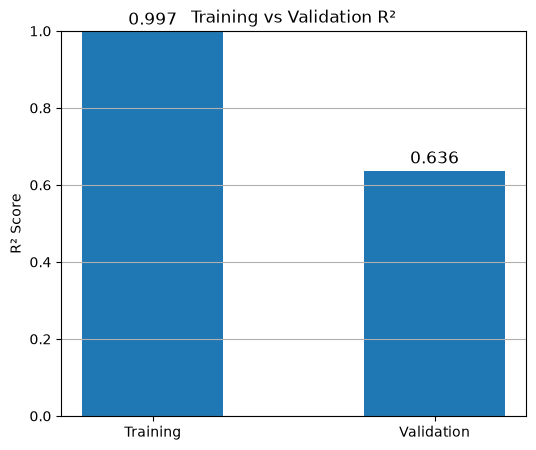

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

train_pred = best_rf.predict(X_train)

val_pred = best_rf.predict(X_validation)

train_r2 = r2_score(y_train, train_pred)
val_r2 = r2_score(y_validation, val_pred)

print("Training R2  :", train_r2)
print("Validation R2:", val_r2)

plt.figure(figsize=(6,5))

plt.bar(
    ["Training", "Validation"],
    [train_r2, val_r2],
    width=0.5
)

plt.ylabel("R² Score")
plt.title("Training vs Validation R²")
plt.ylim(0,1)

for i, v in enumerate([train_r2, val_r2]):
    plt.text(i, v+0.02, f"{v:.3f}", ha="center", fontsize=12)

plt.grid(axis="y")

plt.show()

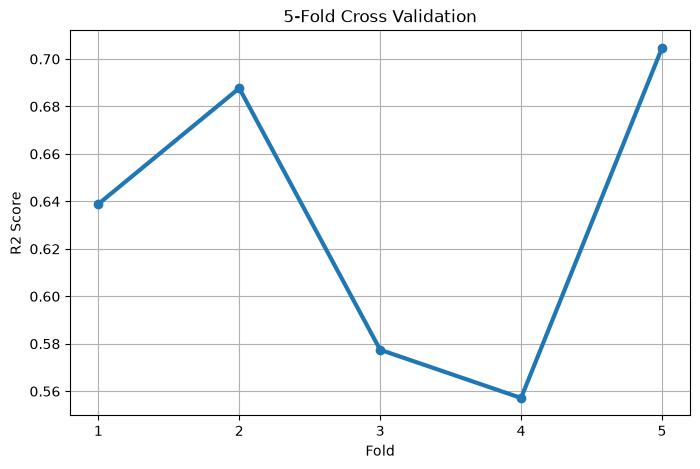

In [19]:
import matplotlib.pyplot as plt

fold = [1,2,3,4,5]

plt.figure(figsize=(8,5))

plt.plot(
    fold,
    scores,
    marker='o',
    linewidth=3
)

plt.xticks(fold)

plt.xlabel("Fold")

plt.ylabel("R2 Score")

plt.title("5-Fold Cross Validation")

plt.grid(True)

plt.show()

In [20]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np
# Training Prediction
train_pred = best_rf.predict(X_train)

# Test / Validation Prediction
test_pred = best_rf.predict(X_validation)
# Training Error
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, train_pred)

# Test Error
test_mse = mean_squared_error(y_validation, test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_validation, test_pred)

print("="*50)
print("TRAINING ERROR")
print("="*50)
print("Training MSE  :", train_mse)
print("Training RMSE :", train_rmse)
print("Training MAE  :", train_mae)

print()

print("="*50)
print("TEST ERROR")
print("="*50)
print("Test MSE  :", test_mse)
print("Test RMSE :", test_rmse)
print("Test MAE  :", test_mae)

TRAINING ERROR
Training MSE  : 0.08796206226825254
Training RMSE : 0.2965839885567873
Training MAE  : 0.021970220049973437

TEST ERROR
Test MSE  : 9.811442033715805
Test RMSE : 3.1323221471802363
Test MAE  : 1.154012054032778


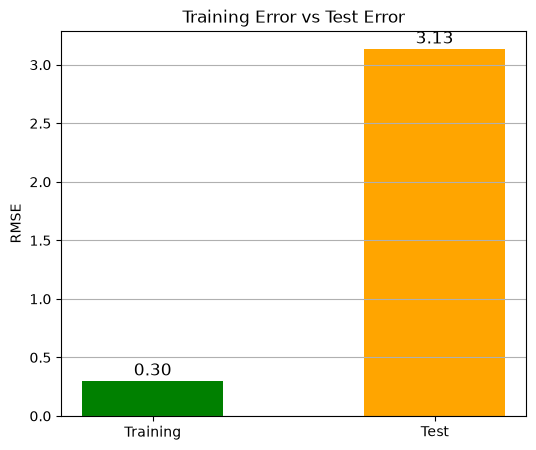

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    ["Training", "Test"],
    [train_rmse, test_rmse],
    width=0.5,
    color=["green","orange"]
)

plt.ylabel("RMSE")
plt.title("Training Error vs Test Error")

for i, v in enumerate([train_rmse, test_rmse]):
    plt.text(i, v+0.05, f"{v:.2f}", ha="center", fontsize=12)

plt.grid(axis="y")

plt.show()

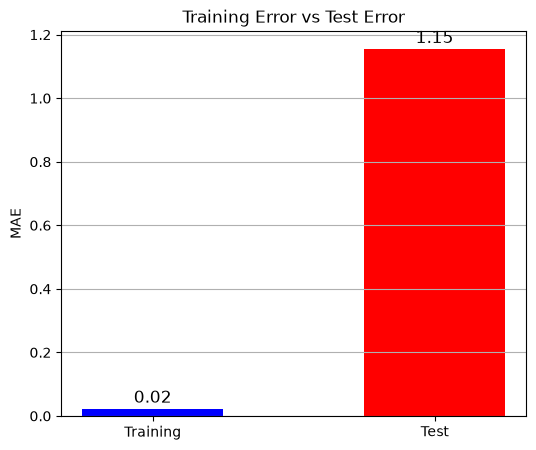

In [22]:
plt.figure(figsize=(6,5))

plt.bar(
    ["Training", "Test"],
    [train_mae, test_mae],
    width=0.5,
    color=["blue","red"]
)

plt.ylabel("MAE")
plt.title("Training Error vs Test Error")

for i, v in enumerate([train_mae, test_mae]):
    plt.text(i, v+0.02, f"{v:.2f}", ha="center", fontsize=12)

plt.grid(axis="y")

plt.show()

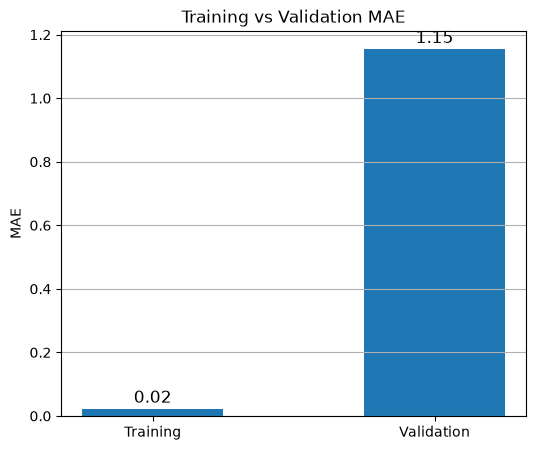

In [23]:
from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(y_train, train_pred)
val_mae = mean_absolute_error(y_validation, val_pred)

plt.figure(figsize=(6,5))

plt.bar(
    ["Training", "Validation"],
    [train_mae, val_mae],
    width=0.5
)

plt.ylabel("MAE")
plt.title("Training vs Validation MAE")

for i, v in enumerate([train_mae, val_mae]):
    plt.text(i, v+0.02, f"{v:.2f}", ha="center", fontsize=12)

plt.grid(axis="y")

plt.show()

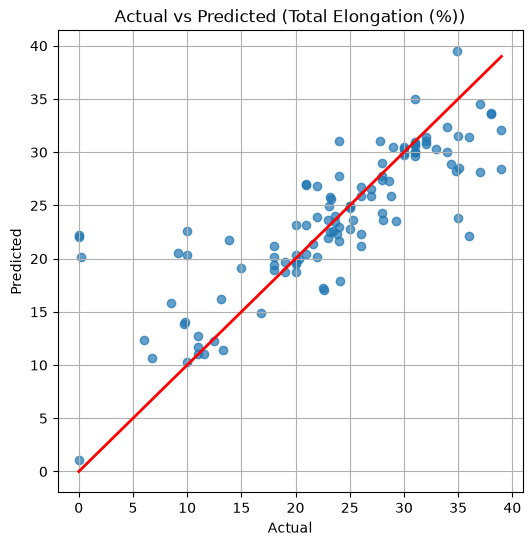

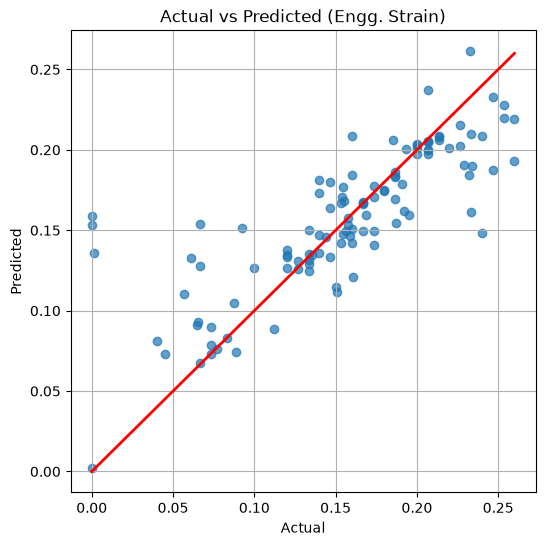

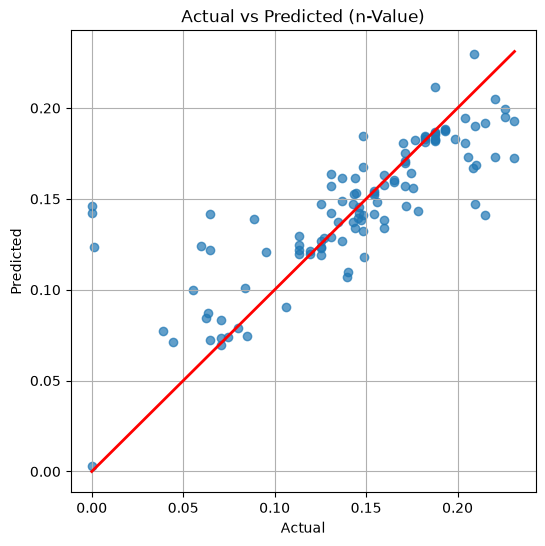

In [24]:
import matplotlib.pyplot as plt

targets = y.columns

for i, target in enumerate(targets):

    plt.figure(figsize=(6,6))

    plt.scatter(
        y_validation.iloc[:, i],
        y_pred[:, i],
        alpha=0.7
    )

    plt.plot(
        [y_validation.iloc[:, i].min(), y_validation.iloc[:, i].max()],
        [y_validation.iloc[:, i].min(), y_validation.iloc[:, i].max()],
        color="red",
        linewidth=2
    )

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Actual vs Predicted ({target})")

    plt.grid(True)

    plt.show()

      Total Elongation (%)  Engg. Strain   n-Value   Average
Mn                0.234607      0.233073  0.240421  0.236034
C                 0.106076      0.105291  0.103723  0.105030
Si                0.086910      0.082461  0.085482  0.084951
Al                0.080346      0.076879  0.079663  0.078963
Cr                0.063869      0.068347  0.064607  0.065608
Mo                0.058406      0.065177  0.064194  0.062592
N                 0.053294      0.055493  0.055300  0.054696
S                 0.053850      0.053917  0.055264  0.054344
Ti                0.051335      0.048821  0.050607  0.050254
B                 0.052817      0.050075  0.046246  0.049713
P                 0.041230      0.044307  0.043215  0.042917
Nb                0.043101      0.041119  0.038142  0.040787
V                 0.020889      0.019816  0.020971  0.020559
Ti*               0.019086      0.018476  0.017772  0.018445
Ca                0.007702      0.007479  0.008130  0.007770
Cu                0.0059

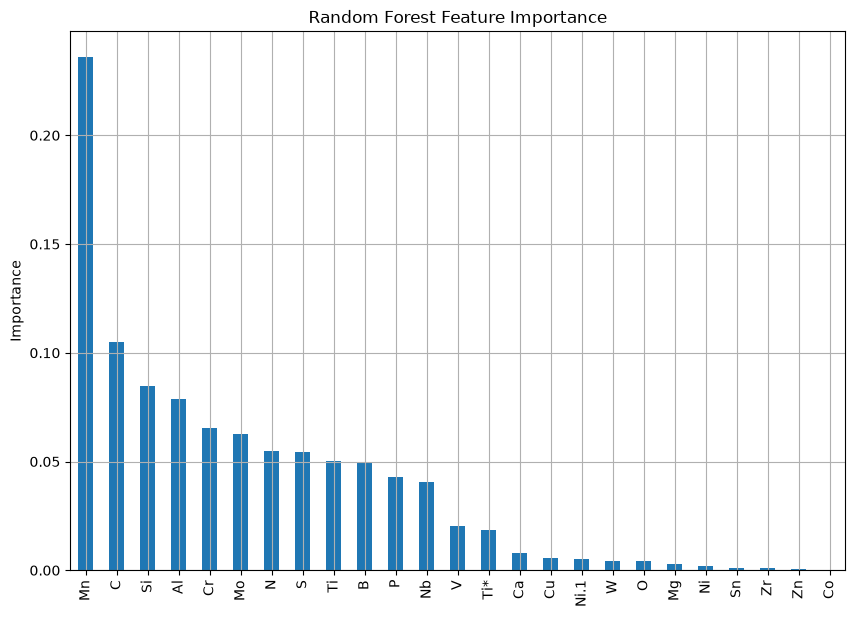

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame()

for i, target in enumerate(y.columns):

    feature_importance[target] = best_rf.estimators_[i].feature_importances_

feature_importance.index = X.columns

feature_importance["Average"] = feature_importance.mean(axis=1)

feature_importance = feature_importance.sort_values(
    by="Average",
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,7))

feature_importance["Average"].plot(kind="bar")

plt.ylabel("Importance")

plt.title("Random Forest Feature Importance")

plt.grid(True)

plt.show()

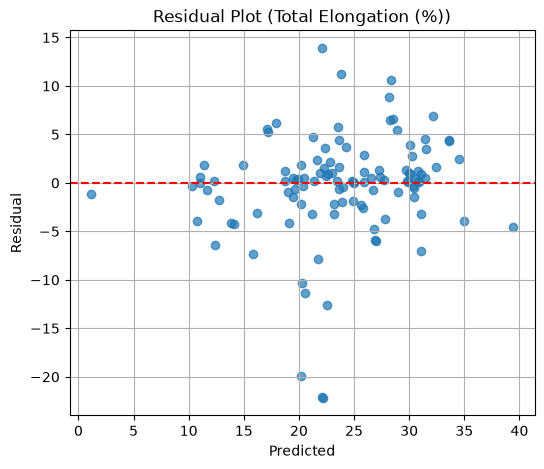

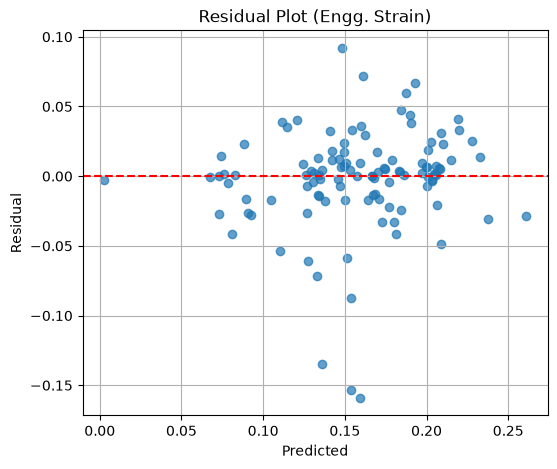

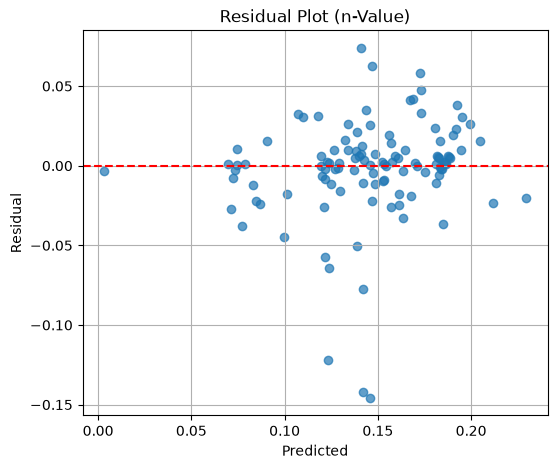

In [26]:
import matplotlib.pyplot as plt

for i, target in enumerate(y.columns):

    residual = y_validation.iloc[:, i] - y_pred[:, i]

    plt.figure(figsize=(6,5))

    plt.scatter(
        y_pred[:, i],
        residual,
        alpha=0.7
    )

    plt.axhline(
        y=0,
        color="red",
        linestyle="--"
    )

    plt.xlabel("Predicted")

    plt.ylabel("Residual")

    plt.title(f"Residual Plot ({target})")

    plt.grid(True)

    plt.show()

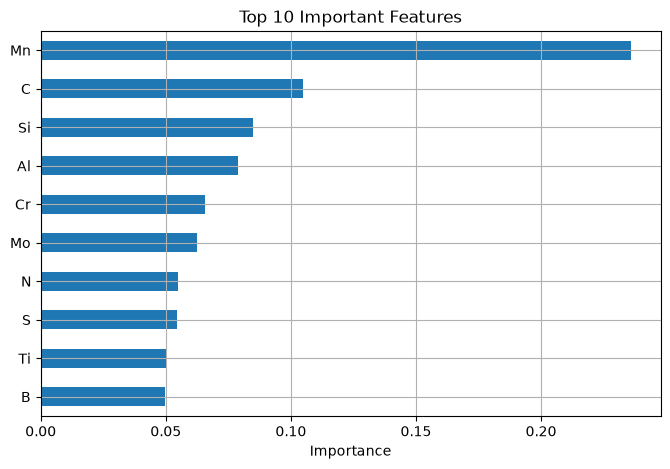

In [27]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,5))

top10["Average"].plot(kind="barh")

plt.xlabel("Importance")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.grid(True)

plt.show()

In [28]:
prediction = y_validation.copy()

prediction = prediction.reset_index(drop=True)

for i, col in enumerate(y.columns):

    prediction[col + "_Predicted"] = y_pred[:, i]

prediction.to_excel(
    "RandomForest_Predictions.xlsx",
    index=False
)

print(prediction.head())

   Total Elongation (%)  Engg. Strain   n-Value  \
0                  35.0      0.233333  0.209721   
1                  29.0      0.193333  0.176751   
2                  20.0      0.133333  0.125163   
3                  23.2      0.154667  0.143812   
4                  36.0      0.240000  0.215111   

   Total Elongation (%)_Predicted  Engg. Strain_Predicted  n-Value_Predicted  
0                       31.528000                0.209982           0.190254  
1                       30.455333                0.200562           0.182601  
2                       19.695000                0.131276           0.123642  
3                       25.809667                0.176973           0.161451  
4                       31.423000                0.208818           0.191804  


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

train_pred = best_rf.predict(X_train)
test_pred = best_rf.predict(X_validation)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
train_r2 = r2_score(y_train, train_pred)

test_rmse = np.sqrt(mean_squared_error(y_validation, test_pred))
test_r2 = r2_score(y_validation, test_pred)

print("="*50)
print("TRAINING SET RESULTS")
print("="*50)
print(f"Training RMSE : {train_rmse:.4f}")
print(f"Training R²   : {train_r2:.4f}")

print()

print("="*50)
print("TEST SET RESULTS")
print("="*50)
print(f"Test RMSE : {test_rmse:.4f}")
print(f"Test R²   : {test_r2:.4f}")

TRAINING SET RESULTS
Training RMSE : 0.2966
Training R²   : 0.9966

TEST SET RESULTS
Test RMSE : 3.1323
Test R²   : 0.6360


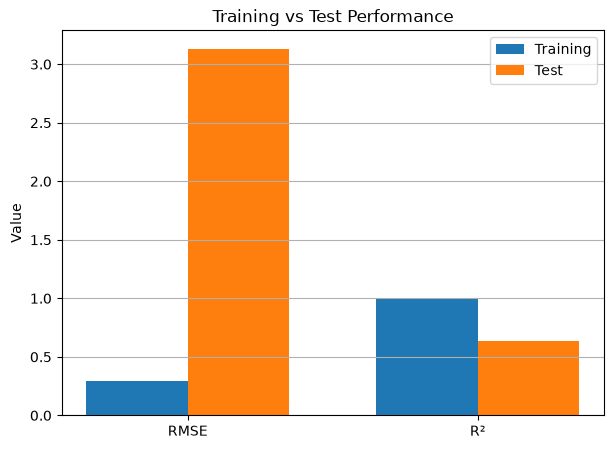

In [30]:
import matplotlib.pyplot as plt

metrics = ["RMSE", "R²"]

train_values = [train_rmse, train_r2]
test_values = [test_rmse, test_r2]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7,5))

plt.bar(x - width/2, train_values, width, label="Training")
plt.bar(x + width/2, test_values, width, label="Test")

plt.xticks(x, metrics)
plt.ylabel("Value")
plt.title("Training vs Test Performance")
plt.legend()
plt.grid(axis="y")

plt.show()